# DocuParse — Notebook do Fluxo Principal de OCR

Executa e visualiza **cada etapa** do pipeline: classificação → preprocessing → OCR primário →
fallback → extração de campos → validação → métricas de qualidade.

| Etapa | Descrição |
|-------|-----------|
| 0 | Configuração |
| 1 | Entrada e preview |
| 2 | Classificação do documento |
| 3 | Resolução do engine |
| 4 | Preprocessing |
| 5 | OCR Primário |
| 6 | Avaliação de fallback (OCR) |
| 7 | OCR Fallback (condicional) |
| 8 | Fallback por qualidade de campo |
| 9 | Extração de campos críticos |
| 10 | Validação dos campos |
| 11 | Métricas de qualidade do pipeline |
| 12 | Resumo final — todos os OCRs executados |


In [16]:
import sys
print(sys.executable)
print("sys.executable is the path to the Python interpreter being used.")

/home/guilherme/repositories/docuparser/.venv/bin/python
sys.executable is the path to the Python interpreter being used.


## Setup — Imports e Configuração do Ambiente

In [17]:
import sys, os, json, time, warnings
from pathlib import Path

# Garante que o módulo backend-ocr esteja no sys.path
BACKEND_DIR = os.path.abspath(".")
if BACKEND_DIR not in sys.path:
    sys.path.insert(0, BACKEND_DIR)

import numpy as np
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# Reduz verbosidade dos engines de OCR
import logging
for _lgr in ["ppocr", "easyocr", "transformers", "paddle", "docling"]:
    logging.getLogger(_lgr).setLevel(logging.WARNING)
warnings.filterwarnings("ignore")

# Registro global de todos os OCRs executados neste run
ocr_results_log = []

print(f"✓ Backend dir: {BACKEND_DIR}")
print("✓ Ambiente configurado — ocr_results_log inicializado")


✓ Backend dir: /home/guilherme/repositories/docuparser/docuparse-project/backend-ocr
✓ Ambiente configurado — ocr_results_log inicializado


## 0. Configuração

Altere `FILE_PATH` para o arquivo que deseja processar.
Deixe `SELECTED_ENGINE = None` para usar o roteamento automático baseado na classificação.


In [18]:
# ── ALTERE AQUI ─────────────────────────────────────────────────────────────

# Caminho do arquivo (relativo à pasta backend-ocr ou absoluto)
# 
FILE_PATH = "tests/pdf/boleto scaneado.pdf"

# Engine: None = auto | "tesseract" | "paddle" | "easyocr" | "trocr"
#         "docling" | "llamaparse" | "deepseek" | "paddle_easyocr"
SELECTED_ENGINE = None

# ────────────────────────────────────────────────────────────────────────────

file_path = Path(FILE_PATH)
assert file_path.exists(), f"Arquivo não encontrado: {FILE_PATH}"

with open(file_path, "rb") as fh:
    file_content = fh.read()

print("=" * 55)
print("  ARQUIVO DE ENTRADA")
print("=" * 55)
print(f"  Nome      : {file_path.name}")
print(f"  Extensão  : {file_path.suffix.upper()}")
print(f"  Tamanho   : {len(file_content):,} bytes  ({len(file_content) / 1024:.1f} KB)")
print(f"  Engine    : {SELECTED_ENGINE!r}  (None = auto-routing)")


  ARQUIVO DE ENTRADA
  Nome      : boleto scaneado.pdf
  Extensão  : .PDF
  Tamanho   : 1,113,470 bytes  (1087.4 KB)
  Engine    : None  (None = auto-routing)


## Etapa 1 — Entrada e Preview do Documento

PDF renderizado — primeira página como imagem
Dimensões : 893 × 1263 px


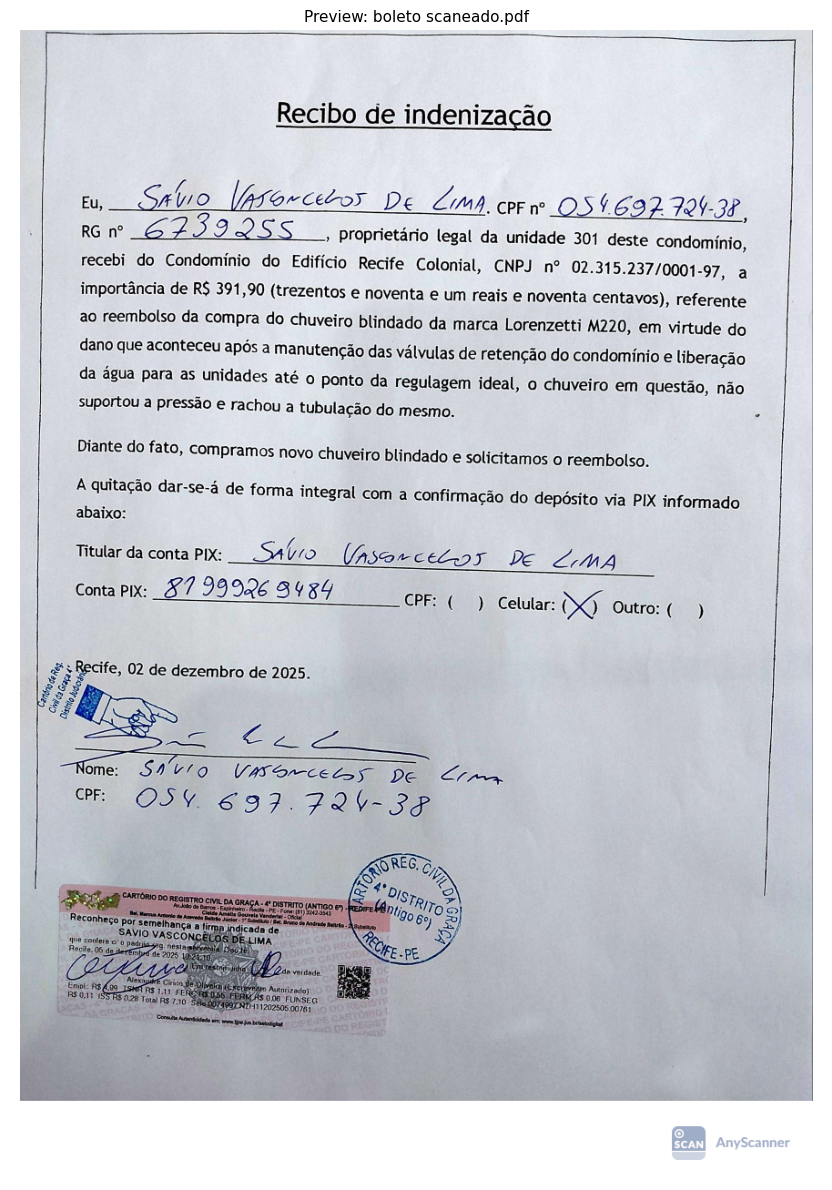

In [19]:
def _render_pdf_page(content: bytes, scale: float = 1.5):
    """Renderiza a primeira página de um PDF como array RGB."""
    import pypdfium2 as pdfium
    pdf = pdfium.PdfDocument(content)
    page = pdf.get_page(0)
    bitmap = page.render(scale=scale)
    return np.array(bitmap.to_pil())

ext = file_path.suffix.lower()
preview_img = None

if ext in {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif", ".webp"}:
    nparr = np.frombuffer(file_content, np.uint8)
    bgr = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    if bgr is not None:
        preview_img = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
elif ext == ".pdf":
    try:
        preview_img = _render_pdf_page(file_content)
        print(f"PDF renderizado — primeira página como imagem")
    except Exception as e:
        print(f"Não foi possível renderizar PDF: {e}")

if preview_img is not None:
    h, w = preview_img.shape[:2]
    print(f"Dimensões : {w} × {h} px")
    fig, ax = plt.subplots(figsize=(9, 12))
    ax.imshow(preview_img)
    ax.set_title(f"Preview: {file_path.name}", fontsize=11)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Preview não disponível para este formato.")


## Etapa 2 — Classificação do Documento

O classificador analisa múltiplos sinais:
- **Nome do arquivo** (tokens semânticos: "manuscrito", "digitalizado", "nota", …)
- **Camada textual do PDF** (quantos caracteres extraíveis existem)
- **Features visuais** via OpenCV (density de bordas, linhas, estrutura tabular, traço irregular)

Possíveis classes: `digital_pdf` · `scanned_image` · `handwritten_complex`


In [20]:
from agent.classifier import classify_document, get_engine_preprocessing_hints_for_class

# Entrada: filename + bytes do arquivo
# Saída  : classe (str)
t0 = time.perf_counter()
classification = classify_document(filename=file_path.name, content=file_content)
classification_ms = (time.perf_counter() - t0) * 1000

# Hints de preprocessing indicados para cada engine nesta classe
preprocessing_hints = get_engine_preprocessing_hints_for_class(classification)

print("=" * 55)
print("  CLASSIFICAÇÃO DO DOCUMENTO")
print("=" * 55)
print(f"  Resultado   : {classification}")
print(f"  Tempo       : {classification_ms:.1f} ms")
print()
print("  Preprocessing hints por engine:")
for eng_name, hint in preprocessing_hints.items():
    print(f"    [{eng_name}] → {hint}")

# Dicionário de capabilities: quais engines atendem cada classe
CAPABILITIES = {
    "digital_pdf"       : ["docling", "llamaparse"],
    "scanned_image"     : ["paddle", "easyocr", "trocr", "tesseract"],
    "handwritten_complex": ["trocr", "paddleocr", "easyocr (mixed)", "signature_tag"],
}
print()
print(f"  Engines disponíveis para '{classification}':")
for eng in CAPABILITIES.get(classification, ["tesseract (fallback)"]):
    print(f"    • {eng}")


INFO:agent.classifier:text_chars_total : 10.000
INFO:agent.classifier:table_score_total total: 0.023
INFO:agent.classifier:handwriting_score_total total: 0.111
INFO:agent.classifier:image_like_pages total: 0
INFO:agent.classifier:Score table: 0.023
INFO:agent.classifier:Score handwriting: 0.111
INFO:agent.classifier:Image-like page ratio: 0.00
INFO:agent.classifier:
Linha 3.1 PDF classified as SCANNED_IMAGE (low text + scanned signal)



  CLASSIFICAÇÃO DO DOCUMENTO
  Resultado   : scanned_image
  Tempo       : 163.1 ms

  Preprocessing hints por engine:
    [paddle] → natural_rgb_with_clahe_and_light_deskew
    [easyocr] → denoise_contrast_deskew_upscale

  Engines disponíveis para 'scanned_image':
    • paddle
    • easyocr
    • trocr
    • tesseract


## Etapa 3 — Resolução do Engine

O roteador escolhe o engine baseado na classificação e no `SELECTED_ENGINE` (se informado).

| Classificação | Engine padrão |
|---|---|
| `digital_pdf` | docling |
| `scanned_image` | paddle (regional pipeline) |
| `handwritten_complex` | pipeline regional (trocr + paddle) |


In [21]:
from agent.router import _resolve_engine

resolved_engine = _resolve_engine(classification, SELECTED_ENGINE)

print("=" * 55)
print("  RESOLUÇÃO DO ENGINE")
print("=" * 55)
print(f"  Classificação     : {classification}")
print(f"  Solicitado        : {SELECTED_ENGINE!r}")
print(f"  Resolvido         : {resolved_engine}")


  RESOLUÇÃO DO ENGINE
  Classificação     : scanned_image
  Solicitado        : None
  Resolvido         : paddle


## Etapa 4 — Preprocessing

O preprocessing é específico por engine e por classe.
Converte o arquivo em bytes de imagem prontos para OCR, aplicando:
deskew, CLAHE, denoising, upscaling, correção de perspectiva, etc.

Para engines nativos de PDF (`docling`, `llamaparse`) o arquivo original é passado
diretamente (sem renderização).


In [22]:
from agent.router import _prepare_content_for_engine, _prepare_content_for_ocr

# handwritten_complex usa pipeline regional; o preprocessing base é feito internamente
if classification == "handwritten_complex":
    prepared_content, input_meta = _prepare_content_for_ocr(file_content, file_path.name)
    print("Preprocessing: pipeline regional interno (Etapa 5 aplica por região)")
else:
    t0 = time.perf_counter()
    prepared_content, input_meta = _prepare_content_for_engine(
        content=file_content,
        filename=file_path.name,
        classification=classification,
        engine_name=resolved_engine,
    )
    prep_ms = (time.perf_counter() - t0) * 1000
    print(f"Preprocessing executado em {prep_ms:.1f} ms")

print()
print("=" * 55)
print("  PREPROCESSING")
print("=" * 55)
print(f"  Engine            : {resolved_engine}")
print(f"  Tipo de entrada   : {input_meta.get('input_type', 'desconhecido')}")
print(f"  Estratégia        : {input_meta.get('engine_preprocessing', 'padrão')}")

steps = input_meta.get("steps", [])
if steps:
    print(f"\n  Passos aplicados ({len(steps)}):")
    for i, step in enumerate(steps, 1):
        print(f"    {i}. {step}")
else:
    print("  Passos: (nenhum registrado — PDF nativo ou padrão)")

if input_meta.get("rendered_from_pdf"):
    print(f"\n  PDF: {input_meta.get('pdf_page_count','?')} páginas → imagem stacked")

print(f"\n  Tamanho pós-preprocessing : {len(prepared_content):,} bytes")


Preprocessing executado em 494.7 ms

  PREPROCESSING
  Engine            : paddle
  Tipo de entrada   : pdf
  Estratégia        : paddleocr

  Passos aplicados (7):
    1. warp_perspective_if_photo
    2. deskew_simple
    3. clahe_local_contrast
    4. denoise_light
    5. equalize_illumination
    6. gaussian_light
    7. upscale_if_low_resolution

  PDF: 1 páginas → imagem stacked

  Tamanho pós-preprocessing : 1,730,194 bytes


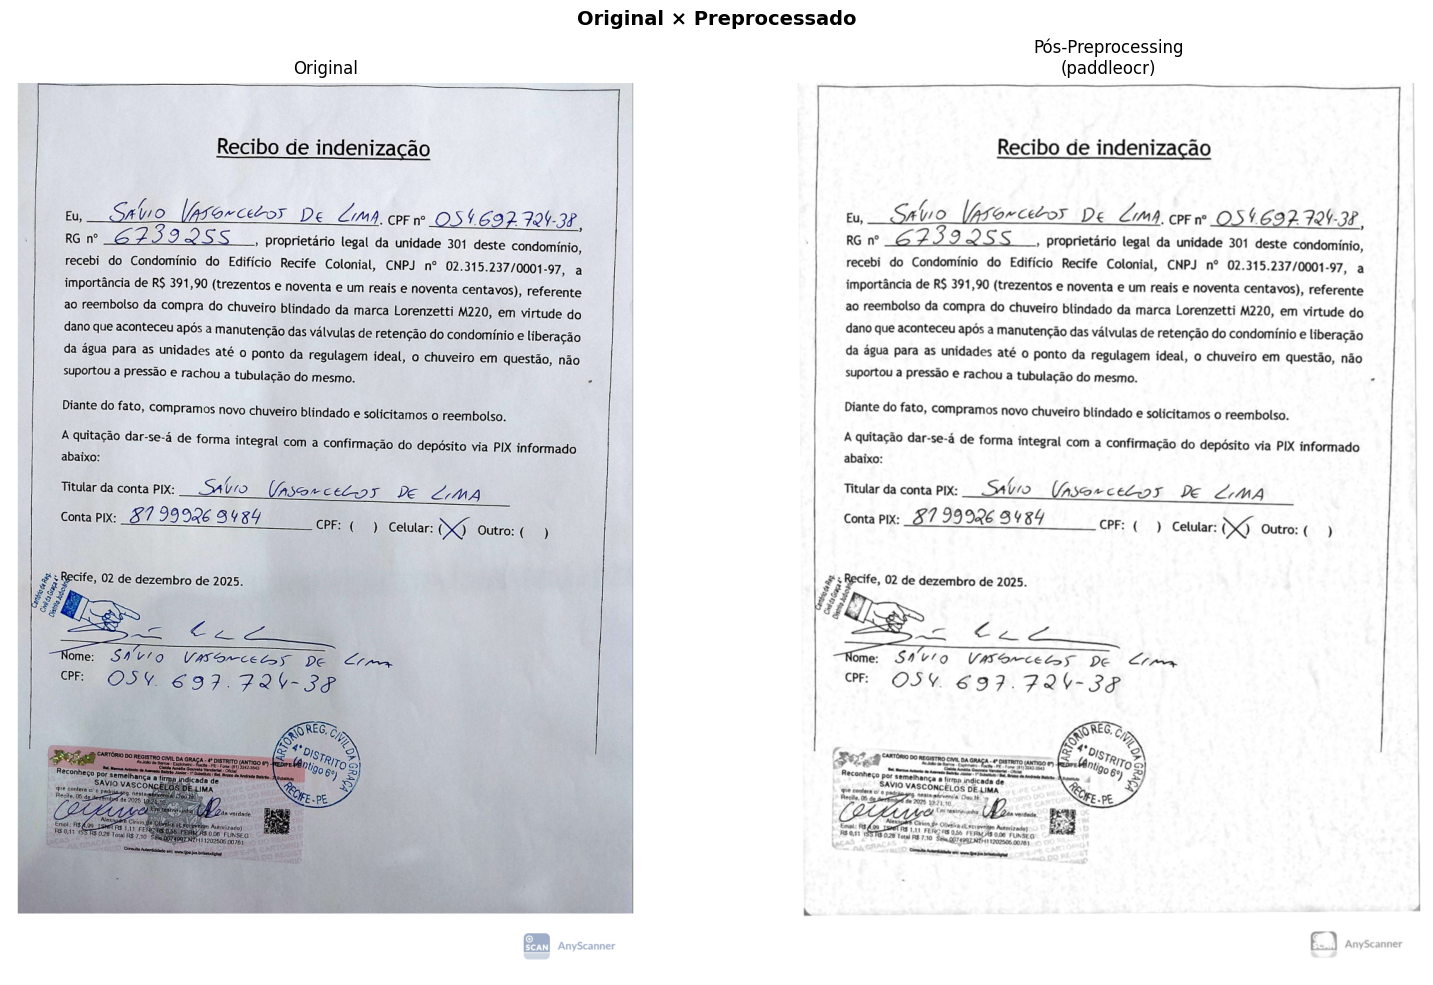

In [23]:
# Visualização: original vs. preprocessado (apenas para imagens/PDFs renderizados)

def _decode_rgb(data):
    if isinstance(data, bytes):
        nparr = np.frombuffer(data, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
        if img is not None:
            return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return None

preprocessed_img = _decode_rgb(prepared_content) if isinstance(prepared_content, bytes) else None
original_img_rgb = preview_img  # calculado na Etapa 1

if original_img_rgb is not None and preprocessed_img is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 10))
    axes[0].imshow(original_img_rgb)
    axes[0].set_title("Original", fontsize=12)
    axes[0].axis("off")
    axes[1].imshow(preprocessed_img)
    axes[1].set_title(
        f"Pós-Preprocessing\n({input_meta.get('engine_preprocessing', 'padrão')})",
        fontsize=12
    )
    axes[1].axis("off")
    plt.suptitle("Original × Preprocessado", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Visualização indisponível (engine nativo de PDF ou formato sem imagem).")


## Etapa 5 — OCR Primário

Executa o engine resolvido na Etapa 3.

**Pipelines especiais:**
- `handwritten_complex` → segmenta regiões (printed / handwritten / signature) e aplica
  o engine mais adequado por região (PaddleOCR para impresso, TrOCR para manuscrito)
- `paddle` → `_process_scanned_by_regions`: pipeline regional por Y-order
- `trocr` → segmenta em linhas antes de alimentar o modelo (TrOCR é single-line)

O resultado (`raw_text`) e os metadados são registrados em `ocr_results_log`.


In [24]:
from agent.router import (
    _process_handwritten_complex_by_regions,
    _process_trocr_page,
    _process_scanned_by_regions,
)
from engines.tesseract_engine import TesseractEngine
from engines.docling_engine   import DoclingEngine
from engines.llamaparse_engine import LlamaParseEngine
from engines.easyocr_engine   import EasyOCREngine
from engines.paddle_engine    import PaddleOCREngine
from engines.trocr_engine     import TrOCREngine
from engines.deepseek_engine  import DeepSeekEngine

print("=" * 55)
print("  OCR PRIMÁRIO")
print("=" * 55)
print(f"  Engine: {resolved_engine}")
print()

t0 = time.perf_counter()
primary_data = {}
primary_input_meta = input_meta

try:
    if classification == "handwritten_complex":
        print("Pipeline: handwritten_complex — segmentação regional (printed/handwritten/signature)")
        primary_data, primary_input_meta = _process_handwritten_complex_by_regions(
            content=file_content, filename=file_path.name
        )

    elif resolved_engine == "tesseract":
        engine = TesseractEngine()
        primary_data = engine.process_with_classification(
            image_bytes=prepared_content, classification=classification
        )

    elif resolved_engine == "docling":
        engine = DoclingEngine()
        primary_data = engine.process(prepared_content)

    elif resolved_engine == "llamaparse":
        engine = LlamaParseEngine()
        primary_data = engine.process(prepared_content)

    elif resolved_engine == "easyocr":
        engine = EasyOCREngine()
        primary_data = engine.process(prepared_content)

    elif resolved_engine in {"paddle", "paddle_easyocr"}:
        print("Pipeline regional: PaddleOCR (impresso) + EasyOCR (manuscrito/misto)")
        primary_data = _process_scanned_by_regions(
            prepared_content=prepared_content, classification=classification
        )

    elif resolved_engine == "trocr":
        print("Pipeline TrOCR: segmentação de regiões → linhas → TrOCR por linha")
        primary_data = _process_trocr_page(prepared_content, classification)

    elif resolved_engine == "deepseek":
        engine = DeepSeekEngine()
        if not engine.is_available():
            raise RuntimeError(f"DeepSeek indisponível: {engine.get_init_error()}")
        primary_data = engine.process(prepared_content)

    else:
        print(f"Engine '{resolved_engine}' não mapeado — Tesseract como fallback")
        engine = TesseractEngine()
        primary_data = engine.process_with_classification(
            image_bytes=prepared_content, classification=classification
        )

except Exception as exc:
    print(f"ERRO no OCR primário: {exc}")
    primary_data = {
        "raw_text": "", "raw_text_fallback": str(exc),
        "_meta": {"error": str(exc), "engine": resolved_engine},
    }

primary_ms = (time.perf_counter() - t0) * 1000

# Garante _meta com tipo e engine para o pipeline de qualidade
if not isinstance(primary_data.get("_meta"), dict):
    primary_data["_meta"] = {}
primary_data["_meta"].setdefault("document_type", classification)
primary_data["_meta"].setdefault("engine", resolved_engine)

primary_meta     = primary_data.get("_meta", {})
primary_raw_text = primary_data.get("raw_text") or primary_data.get("raw_text_fallback") or ""
primary_avg_conf = primary_meta.get("avg_confidence")

print(f"  Tempo             : {primary_ms:.0f} ms")
print(f"  Caracteres        : {len(primary_raw_text):,}")
print(f"  Tokens            : {len(primary_raw_text.split()):,}")
print(f"  Confiança média   : {primary_avg_conf if primary_avg_conf is not None else 'N/A'}")

# Segmentação regional (se aplicável)
seg = primary_meta.get("segmentation", {})
if seg:
    print(f"\n  Segmentação regional ({seg.get('total_regions','?')} regiões):")
    for rtype in ["printed_regions", "handwritten_regions", "mixed_regions", "signature_regions"]:
        n = seg.get(rtype)
        if n:
            print(f"    {rtype.replace('_regions','').title():<12}: {n}")

# ── Registra no log de OCRs
ocr_results_log.append({
    "step"                  : "primary",
    "engine"                : resolved_engine,
    "role"                  : "Primário",
    "classification"        : classification,
    "preprocessing_strategy": primary_input_meta.get("engine_preprocessing", "padrão"),
    "preprocessing_steps"   : primary_input_meta.get("steps", []),
    "raw_text"              : primary_raw_text,
    "raw_text_length"       : len(primary_raw_text),
    "token_count"           : len(primary_raw_text.split()),
    "avg_confidence"        : primary_avg_conf,
    "processing_time_ms"    : round(primary_ms, 1),
    "meta": {
        k: v for k, v in primary_meta.items()
        if k not in {"confidence_by_term", "conversion_time_by_term"}
    },
})

print("\n✓ Resultado registrado em ocr_results_log[0]")


  OCR PRIMÁRIO
  Engine: paddle

Pipeline regional: PaddleOCR (impresso) + EasyOCR (manuscrito/misto)


KeyboardInterrupt: 

In [ ]:
# Exibe o texto bruto extraído pelo OCR primário
MAX_CHARS = 3000
print("=" * 55)
print(f"  RAW TEXT — OCR PRIMÁRIO  ({len(primary_raw_text):,} chars)")
print("=" * 55)
print()
print(primary_raw_text[:MAX_CHARS])
if len(primary_raw_text) > MAX_CHARS:
    print(f"\n... [truncado — exibidos {MAX_CHARS} de {len(primary_raw_text)} caracteres]")


  RAW TEXT — OCR PRIMÁRIO  (2,767 chars)

DANFSe v1.0
Documento Auxiliar da NFS-e
Prefeitura do Recife
Secretaria de Finanças
faleconosco@recife.pe.gov.br
Chave de Acesso da NFS-e
26116062208629869000101000000000000625120022507574
A autenticidade desta NFS-e pode ser verificada
pela leitura deste código QR ou pela consulta da
chave de acesso no portal nacional da NFS-e
Número da NFS-e
6
Competência da NFS-e
12/12/2025
Data e Hora da emissão da NFS-e
12/12/2025 15:44:48
Número da DPS
11
Série da DPS
900
Data e Hora da emissão da DPS
12/12/2025 15:44:47
EMITENTE DA NFS-e
Prestador do Serviço
CNPJ / CPF / NIF
08.629.869/0001-01
Inscrição Municipal
6331840
Telefone
(81) 9975-2227
Nome / Nome Empresarial
MUNOZ, PEREIRA E VASCONCELOS ADVOGADOS ASSOCIADOS
E-mail
mpv.adv@hotmail.com
Endereço
RUA CORONEL JOAO RUFINO, 42, POCO
Município
Recife - PE
CEP
52061-110
Simples Nacional na Data de Competência
Optante - Microempresa ou Empresa de Pequeno Porte (ME/EPP)
Regime de Apuração Tributária pelo 

## Etapa 6 — Avaliação de Fallback (OCR)

`should_trigger_fallback()` combina três sinais:
1. **Confiança média** do OCR < 70 %
2. **Qualidade de campos** (`compute_field_pipeline_quality`) indica `fallback_needed`
3. **Cobertura de texto** muito baixa (< 80 chars ou < 15 tokens)


In [ ]:
from utils.ocr_fallback import should_trigger_fallback
from utils.validate_fields import extract_avg_confidence

avg_conf_val = extract_avg_confidence(primary_data)
ocr_fallback_needed = should_trigger_fallback(primary_data)

print("=" * 55)
print("  AVALIAÇÃO DE FALLBACK (OCR)")
print("=" * 55)
print(f"  Confiança média OCR   : {f'{avg_conf_val:.1f}%' if avg_conf_val is not None else 'N/A'}")
print(f"  Threshold             : 70%")
print(f"  Tokens extraídos      : {len(primary_raw_text.split())}")
print(f"  Threshold tokens      : 15")
print()
status = "✅ SIM — fallback será executado" if ocr_fallback_needed else "❌ NÃO — qualidade OK"
print(f"  Fallback necessário?  : {status}")


  AVALIAÇÃO DE FALLBACK (OCR)
  Confiança média OCR   : 87.7%
  Threshold             : 70%
  Tokens extraídos      : 399
  Threshold tokens      : 15

  Fallback necessário?  : ❌ NÃO — qualidade OK


## Etapa 7 — OCR Fallback (condicional)

Executado apenas quando `should_trigger_fallback` retornou `True`.
O engine de fallback é determinado por `resolve_field_fallback_engine()` com base
na classificação e no engine primário.


In [ ]:
from utils.validate_fields import resolve_field_fallback_engine
from utils.ocr_fallback import is_engine_error_fallback, merge_fallback_result
from agent.router import _run_engine_by_name

merged_data = primary_data  # default: usa dados primários

if ocr_fallback_needed:
    fallback_engine_name = resolve_field_fallback_engine(classification, resolved_engine)

    if classification == "handwritten_complex" and fallback_engine_name in {None, "easyocr", "paddle"}:
        fallback_engine_name = "trocr"

    print("=" * 55)
    print("  OCR FALLBACK")
    print("=" * 55)
    print(f"  Engine de fallback: {fallback_engine_name!r}")

    if fallback_engine_name:
        from agent.router import _prepare_content_for_engine as _prep

        try:
            fallback_prepared, fallback_imeta = _prep(
                content=file_content,
                filename=file_path.name,
                classification=classification,
                engine_name=fallback_engine_name,
            )

            t0 = time.perf_counter()
            fallback_data = _run_engine_by_name(
                engine_name=fallback_engine_name,
                classification=classification,
                content=file_content,
                filename=file_path.name,
            )
            fallback_ms = (time.perf_counter() - t0) * 1000

        except Exception as fb_err:
            print(f"  ⚠️  Fallback falhou: {fb_err}")
            fallback_data = None
            fallback_ms = 0.0
            fallback_imeta = {}

        if fallback_data and not is_engine_error_fallback(fallback_data):
            fb_meta     = fallback_data.get("_meta") or {}
            fb_raw_text = fallback_data.get("raw_text") or fallback_data.get("raw_text_fallback") or ""
            fb_avg_conf = fb_meta.get("avg_confidence")

            print(f"\n  Tempo             : {fallback_ms:.0f} ms")
            print(f"  Caracteres        : {len(fb_raw_text):,}")
            print(f"  Tokens            : {len(fb_raw_text.split()):,}")
            print(f"  Confiança média   : {fb_avg_conf if fb_avg_conf is not None else 'N/A'}")

            # Registra no log
            ocr_results_log.append({
                "step"                  : "ocr_fallback",
                "engine"                : fallback_engine_name,
                "role"                  : "Fallback OCR",
                "classification"        : classification,
                "preprocessing_strategy": fallback_imeta.get("engine_preprocessing", "padrão"),
                "preprocessing_steps"   : fallback_imeta.get("steps", []),
                "raw_text"              : fb_raw_text,
                "raw_text_length"       : len(fb_raw_text),
                "token_count"           : len(fb_raw_text.split()),
                "avg_confidence"        : fb_avg_conf,
                "processing_time_ms"    : round(fallback_ms, 1),
                "meta": {
                    k: v for k, v in fb_meta.items()
                    if k not in {"confidence_by_term", "conversion_time_by_term"}
                },
            })

            merged_data = merge_fallback_result(
                primary_data, fallback_data,
                primary_engine=resolved_engine,
                fallback_engine=fallback_engine_name,
            )

            print()
            MAX_CHARS = 2000
            print(f"  RAW TEXT — FALLBACK OCR  ({len(fb_raw_text):,} chars):")
            print("-" * 40)
            print(fb_raw_text[:MAX_CHARS])
            if len(fb_raw_text) > MAX_CHARS:
                print(f"... [truncado — {len(fb_raw_text)} chars total]")

            print("\n✓ Fallback registrado em ocr_results_log")
        else:
            print("  ⚠️  Fallback não produziu resultado utilizável — mantendo dados primários")
    else:
        print(f"  Nenhum engine de fallback mapeado para classification={classification!r}")

else:
    print("Fallback OCR não necessário (qualidade primária OK).")


## Etapa 8 — Fallback por Qualidade de Campo

Após o OCR (primário + possível fallback de confiança), avalia-se se os campos críticos
foram extraídos com qualidade suficiente. Se `fallback_needed=True`, um segundo engine
é usado para preencher campos faltantes via `merge_fields_by_validation`.


In [ ]:
from utils.validate_fields import (
    compute_field_pipeline_quality,
    resolve_field_fallback_engine,
    merge_fields_by_validation,
    merge_field_confidence,
    extract_avg_confidence as _avg_conf,
)
from utils.ocr_fallback import is_engine_error_fallback as _is_err

# Avalia qualidade com os dados atuais (pós-merge se houve fallback OCR)
fq = compute_field_pipeline_quality(merged_data)
field_fallback_needed = fq.get("fallback_needed", False)

print("=" * 55)
print("  FALLBACK POR QUALIDADE DE CAMPO")
print("=" * 55)
print(f"  final_score atual     : {fq.get('final_score', 0):.4f}")
print(f"  field_score           : {fq.get('field_score', 0):.4f}")
print(f"  fallback_needed       : {field_fallback_needed}")

if field_fallback_needed:
    field_fallback_engine = resolve_field_fallback_engine(classification, resolved_engine)

    if classification == "handwritten_complex" and field_fallback_engine in {None, "easyocr", "paddle"}:
        field_fallback_engine = "trocr"

    print(f"  Engine de fallback    : {field_fallback_engine!r}")

    if field_fallback_engine:
        from agent.router import _run_engine_by_name as _run
        from agent.router import _prepare_content_for_engine as _prep

        try:
            ff_prepared, ff_imeta = _prep(
                content=file_content,
                filename=file_path.name,
                classification=classification,
                engine_name=field_fallback_engine,
            )

            t0 = time.perf_counter()
            ff_data = _run(
                engine_name=field_fallback_engine,
                classification=classification,
                content=file_content,
                filename=file_path.name,
            )
            ff_ms = (time.perf_counter() - t0) * 1000

        except Exception as ff_err:
            print(f"  ⚠️  Field fallback falhou: {ff_err}")
            ff_data = None
            ff_ms = 0.0
            ff_imeta = {}

        if ff_data and not _is_err(ff_data):
            if not isinstance(ff_data.get("_meta"), dict):
                ff_data["_meta"] = {}
            ff_data["_meta"].setdefault("document_type", classification)
            ff_data["_meta"].setdefault("engine", field_fallback_engine)

            ff_quality = compute_field_pipeline_quality(ff_data)
            merged_fields, fields_from_fb = merge_fields_by_validation(
                primary_fields=fq["fields"],
                fallback_fields=ff_quality["fields"],
                fallback_validation=ff_quality["validation"],
            )

            merged_conf_pct = max(
                _avg_conf(merged_data) or 0.0,
                _avg_conf(ff_data)     or 0.0,
            )
            merged_field_conf = merge_field_confidence(
                primary_confidence=fq.get("field_confidence", {}),
                fallback_confidence=ff_quality.get("field_confidence", {}),
                fields_from_fallback=fields_from_fb,
            )
            fq = compute_field_pipeline_quality(
                merged_data,
                override_fields=merged_fields,
                override_ocr_confidence=merged_conf_pct,
                override_field_confidence=merged_field_conf,
            )

            ff_meta     = ff_data.get("_meta", {})
            ff_raw_text = ff_data.get("raw_text") or ff_data.get("raw_text_fallback") or ""
            ff_avg_conf = ff_meta.get("avg_confidence")

            print(f"\n  Campos preenchidos pelo fallback: {fields_from_fb}")
            print(f"  Tempo              : {ff_ms:.0f} ms")
            print(f"  Caracteres         : {len(ff_raw_text):,}")
            print(f"  Confiança média    : {ff_avg_conf if ff_avg_conf is not None else 'N/A'}")

            # Registra no log
            ocr_results_log.append({
                "step"                  : "field_fallback",
                "engine"                : field_fallback_engine,
                "role"                  : "Fallback de Campo",
                "classification"        : classification,
                "preprocessing_strategy": ff_imeta.get("engine_preprocessing", "padrão"),
                "preprocessing_steps"   : ff_imeta.get("steps", []),
                "raw_text"              : ff_raw_text,
                "raw_text_length"       : len(ff_raw_text),
                "token_count"           : len(ff_raw_text.split()),
                "avg_confidence"        : ff_avg_conf,
                "processing_time_ms"    : round(ff_ms, 1),
                "fields_from_fallback"  : fields_from_fb,
                "meta": {
                    k: v for k, v in ff_meta.items()
                    if k not in {"confidence_by_term", "conversion_time_by_term"}
                },
            })

            print()
            print(f"  RAW TEXT — FIELD FALLBACK OCR  ({len(ff_raw_text):,} chars):")
            print("-" * 40)
            print(ff_raw_text[:2000])
            if len(ff_raw_text) > 2000:
                print(f"... [truncado]")

            print("\n✓ Field fallback registrado em ocr_results_log")
        else:
            print("  ⚠️  Field fallback não produziu resultado utilizável")
    else:
        print("  Nenhum engine de fallback de campo disponível")
else:
    print("  Qualidade de campos OK — fallback de campo não necessário")


## Etapa 9 — Extração de Campos Críticos

Campos obrigatórios (REQUIRED_FIELDS):
`fornecedor` · `tomador` · `cnpj_fornecedor` · `numero_nf` · `descricao_servico` · `valor_nf` · `retencao`

A extração usa blocos semânticos de NFS-e quando disponíveis, depois heurísticas e regex.


In [ ]:
from utils.validate_fields import extract_critical_fields_with_confidence, REQUIRED_FIELDS

# Usa fq (field quality) já calculado na Etapa 8 se disponível, ou calcula agora
if "fields" in fq:
    fields         = fq["fields"]
    field_confidence = fq.get("field_confidence", {})
else:
    t0 = time.perf_counter()
    fields, field_confidence = extract_critical_fields_with_confidence(merged_data)
    print(f"Extração em {(time.perf_counter()-t0)*1000:.1f} ms")

print("=" * 55)
print("  CAMPOS EXTRAÍDOS")
print("=" * 55)
print(f"  {'Campo':<22} {'Confiança':>9}   Valor")
print(f"  {'-'*22} {'-'*9}   {'-'*30}")
for field_name in REQUIRED_FIELDS:
    value  = fields.get(field_name, "")
    conf   = field_confidence.get(field_name, 0.0)
    trunc  = (value[:50] + "…") if len(value) > 52 else value
    print(f"  {field_name:<22} {conf:>8.0%}   {trunc}")


## Etapa 10 — Validação dos Campos

In [ ]:
from utils.validate_fields import validate_fields

validation = validate_fields(fields)

print("=" * 55)
print("  VALIDAÇÃO DOS CAMPOS")
print("=" * 55)
for key, result in validation.items():
    if key in {"required_fields_present", "cnpj_tomador_validado"}:
        continue
    emoji = "✅" if result else "❌"
    print(f"  {emoji}  {key}: {result}")

print()
print("  Campos obrigatórios presentes:")
req_present = validation.get("required_fields_present", {})
for fname, present in req_present.items():
    emoji = "✅" if present else "⚠️ "
    print(f"  {emoji}  {fname}: {'sim' if present else 'AUSENTE'}")


## Etapa 11 — Métricas de Qualidade do Pipeline

**Fórmula do final_score:**
```
final_score = (0.4 × ocr_confidence) + (0.6 × field_score)
```

- `ocr_confidence`: confiança média do OCR engine (0–1)
- `field_score`: razão de flags de validação verdadeiros sobre o total
- Threshold de baixa confiança: **0.75 (75 %)**


In [ ]:
from utils.validate_fields import LOW_CONFIDENCE_THRESHOLD

# fq já contém o resultado da última avaliação (Etapa 8)
ocr_conf    = fq.get("ocr_confidence", 0.0)
field_score = fq.get("field_score",    0.0)
final_score = fq.get("final_score",    0.0)
fb_needed   = fq.get("fallback_needed", False)

print("=" * 55)
print("  MÉTRICAS DE QUALIDADE DO PIPELINE")
print("=" * 55)
print(f"  ocr_confidence  : {ocr_conf:.4f}  ({ocr_conf * 100:.1f}%)")
print(f"  field_score     : {field_score:.4f}  ({field_score * 100:.1f}%)")
print(f"  final_score     : {final_score:.4f}  ({final_score * 100:.1f}%)")
print()
print(f"  Fórmula:")
print(f"    (0.4 × {ocr_conf:.4f}) + (0.6 × {field_score:.4f}) = {final_score:.4f}")
print()
print(f"  Threshold baixa confiança : {LOW_CONFIDENCE_THRESHOLD:.0%}")
if final_score >= LOW_CONFIDENCE_THRESHOLD:
    print(f"  Avaliação : ✅  Boa confiança! Valores extraídos corretamente")
else:
    print(f"  Avaliação : ⚠️   Confiança média baixa — recomenda-se inserção manual")
print()
print(f"  Fallback de campo necessário : {'Sim' if fb_needed else 'Não'}")
print(f"  LLM deveria rodar           : {fq.get('llm_should_run', False)}")

# Score por campo crítico
print()
print("  Score por campo crítico (threshold = 0.75):")
field_scores = fq.get("critical_field_scores", {})
for fname in REQUIRED_FIELDS:
    score   = field_scores.get(fname, 0.0)
    bar_len = int(score * 25)
    bar     = "█" * bar_len + "░" * (25 - bar_len)
    flag    = "✅" if score >= LOW_CONFIDENCE_THRESHOLD else "⚠️ "
    print(f"  {flag} {fname:<22} [{bar}] {score:.2f}")

# Score por campo — gráfico de barras
fig, ax = plt.subplots(figsize=(8, 4))
names  = list(REQUIRED_FIELDS)
scores = [field_scores.get(n, 0.0) for n in names]
colors = ["#22c55e" if s >= LOW_CONFIDENCE_THRESHOLD else "#f59e0b" for s in scores]
bars = ax.barh(names, scores, color=colors, edgecolor="white", height=0.5)
ax.axvline(LOW_CONFIDENCE_THRESHOLD, color="#ef4444", linestyle="--", linewidth=1.5,
           label=f"Threshold ({LOW_CONFIDENCE_THRESHOLD:.0%})")
ax.set_xlim(0, 1)
ax.set_xlabel("Score")
ax.set_title("Scores dos campos críticos")
ax.legend()
for bar, score in zip(bars, scores):
    ax.text(min(score + 0.01, 0.98), bar.get_y() + bar.get_height() / 2,
            f"{score:.2f}", va="center", ha="left" if score < 0.9 else "right", fontsize=9)
plt.tight_layout()
plt.show()


## Resumo Final — Registro de Todos os OCRs Executados

Lista JSON completa com `raw_text` e métricas de cada engine executado neste run.


In [ ]:
print("=" * 70)
print("  REGISTRO COMPLETO DOS OCRs EXECUTADOS")
print("=" * 70)

for i, entry in enumerate(ocr_results_log, 1):
    print()
    print(f"  ─── OCR #{i}: {entry['engine'].upper()} ({entry['role']}) ───────────────────")
    print(f"    Preprocessing   : {entry.get('preprocessing_strategy', 'padrão')}")
    if entry.get('preprocessing_steps'):
        print(f"    Passos          : {entry['preprocessing_steps']}")
    print(f"    Confiança média : {entry.get('avg_confidence', 'N/A')}")
    print(f"    Tempo           : {entry.get('processing_time_ms', 'N/A')} ms")
    print(f"    Caracteres      : {entry.get('raw_text_length', 0):,}")
    print(f"    Tokens          : {entry.get('token_count', 0):,}")
    if entry.get("fields_from_fallback"):
        print(f"    Campos do FB    : {entry['fields_from_fallback']}")
    rt = entry.get("raw_text", "")
    preview = rt[:400] if rt else "(vazio)"
    print(f"\n    raw_text (primeiros 400 chars):")
    print(f"    {preview!r}")

print()
print("=" * 70)
print("  MÉTRICAS FINAIS")
print("=" * 70)
print(f"  Engines executados : {[e['engine'] for e in ocr_results_log]}")
print(f"  ocr_confidence     : {fq.get('ocr_confidence', 0):.4f}")
print(f"  field_score        : {fq.get('field_score', 0):.4f}")
print(f"  final_score        : {fq.get('final_score', 0):.4f}")
result_msg = (
    "✅ Boa confiança! Valores extraídos corretamente"
    if fq.get("final_score", 0) >= LOW_CONFIDENCE_THRESHOLD
    else "⚠️  Confiança média baixa — recomenda-se inserção manual"
)
print(f"  Avaliação          : {result_msg}")


In [ ]:
# Exporta o log completo como JSON estruturado
log_export = {
    "arquivo"         : file_path.name,
    "classificacao"   : classification,
    "engine_primario" : resolved_engine,
    "ocr_results"     : [
        {
            "engine"                 : e["engine"],
            "role"                   : e["role"],
            "preprocessing_strategy" : e.get("preprocessing_strategy", "padrão"),
            "preprocessing_steps"    : e.get("preprocessing_steps", []),
            "raw_text"               : e["raw_text"],
            "raw_text_length"        : e["raw_text_length"],
            "token_count"            : e["token_count"],
            "avg_confidence"         : e.get("avg_confidence"),
            "processing_time_ms"     : e.get("processing_time_ms"),
            "fields_from_fallback"   : e.get("fields_from_fallback", []),
        }
        for e in ocr_results_log
    ],
    "campos_extraidos": {k: v for k, v in fields.items() if v},
    "metricas": {
        "ocr_confidence" : fq.get("ocr_confidence", 0),
        "field_score"    : fq.get("field_score",    0),
        "final_score"    : fq.get("final_score",    0),
        "fallback_needed": fq.get("fallback_needed", False),
        "llm_should_run" : fq.get("llm_should_run", False),
    },
}

print(json.dumps(log_export, ensure_ascii=False, indent=2))
